In [ ]:
#0. PREVIEW AND GOALS
#The goal of this program is analyzing the bases which changed, considering a max of 92 bases
#FIRSTLY, we want to create a probability density function to understand what are the most common number of 
#ALLELE VARIATIONS FREQUENCIES (AVARs frequencies)
#SECONDLY, we'll evaluate the impact of recombination and evolution in different segments of adjacent SNPs through
#the analysis of consecutive, tree-compatible SNPs based on the 4-gamete-theory.

#all of this occurs along the genome of 92 E.coli species


#in the previous exercise, when we had a  a BioPython object, the library directly uses the strings
#where the genomes are located when an iterative cycle is used.
#But there, the comparison was between two strings, not between 92 elements each time.

#The exercise here required a different approach, mantainable for both our goals.
#For every single base, we need to find the usual nucleotyde. 90% of the original columns show no variation 
#It's very unlikely to have more than 2 nucleotydes assigned for a single base, and it's not that interesting compared
#to the occurence of a variation (it is super unlikely in hereditary terms that a base goes like a->t->g).
#To facilitate our counting for the frequency of SNPs, the best idea is to develop a binary comparison between the usual 
#nucleotyde (0) and SNPs
# here there are more than 2 letters for a single genomethat need to be binarized to create then
#SNP probability distributions. Therefore, changing all the heritages from strings into numerical lists/arrays is
#absolutely crucial in order to then create a PDF.

#1-2 IMPORTING DATA, CREATING THEMAIN INDEXING AND FILTERING THE ORIGINAL AMTRIX TO GET ONLY THE SNP AND USEFUL INFORMATION through indexes

#3-4 ABSOLUTE ALLELE VARIATION FREQUENCY EVALUATION, probability mass function of the number of allele variations for each base
#seeing spikes in these plots in a number n helps us understand if n species have a further common ancestor, and strongly separated 
# with the others

#5-6-7-8 Given a certain number of allel variations, creating a Rank Frequency Plot AND a nCDF of the unique allele variation patterns
# for each length (how many times the same column appear among it's equally-numbered). Estimating each function as the optimal
#power-log function (k/x^alfa function) and, given each number of allele variations, putting all the related alphas in a plot.
#Seeing spikes in the rfp and the nCDF for numbers that peak in the previous plot corroborates this separate evolution from all the others

#9-10-11 calulating the length of tree-compatible n-SNPs to understand how much recombination is affecting the bacterias development

#12-13-14
#Calculating the absolute number of clashes per kb zone inside the core genome. This can suggest to us how much a zone has evolved throughout
#recombination, however it is not as trustworthy as the clashes/mutation ratio to understand how much recombination, compared
#to natural mutation, has happened

#15 Studying the clash-mutation ratio for each kb to have a clearer picture

#16 For each n-dimensional SNPs, evaluating the number of CLASHES inside them (10-20-30-40). Impressively accurate matches with the Poisson
#function, this comparison wasn't in the paper.



In [45]:
#1. BASIC IMPORTS, DIMENSION DEFINITION AND BioPython object -> Numpy Array conversion
from Bio import AlignIO 
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import random
import scipy
from scipy.stats import poisson

format_type = 'phylip-relaxed'
phy_file = '/home/tommaso_cappelli_05/bzrs/ecoli_samples/core_alignment.phy'

alignment = AlignIO.read(phy_file, format_type)

num_bacteria = len(alignment)
n_bases = len(alignment[0])
print(num_bacteria)
print(n_bases)

#now, what I need to understand is that to use scipy I have to switch from a complicated type of data
# to integers. The data we're startng from is the BioPython object, who has features such as ID, Name, description
#and the sequence we're actually interested in. From a list of objects, which is alignment, i need to switch to a list of 
#the numerical-equivalent of sequences: I'll do this row by row.


og_matrix = []                   # 1. Create an empty list to store the genomic sequence
for rec in alignment:             # 2. Start looping through the alignment
    letters = list(rec.seq)       # 3. Extract the sequence and split it into letters
    og_matrix.append(letters)    # 4. Add those letters to our list
    
og_matrix = np.array(og_matrix)

92
2593095


In [46]:
#2. SWITCHING TO NUMBERS (ascii), ISOLATING THE COLUMNS WITH SNPs, EVALUATING THE COLUMNS' MODES AND BINARIZING

# to use Scipy and its stats library, we can't interpret anything as a letter. Therefore, what we do is to assign the
#same address as a new variable, that will have to read the data as numeric. If og_matrix_ASCII was modified, the same would
#happen to og_matrix_ASCII, that would still read everything as straight up ASCII numbers.
og_matrix_ASCII = og_matrix.view(np.int32)

#it would be really useful to cancel the columns from the matrix when they have all the same number, since we have no interest
#in a column if there's no SNPs in it right now.
#In the previous exercise, there could be a max of 100 SNPs per kb, but this means that most of the bases actually don't mutate
#at all.
#FILTER FOR THE PRESENCE OF 3+ LETTERS IN THE SAME BASE COLUMN


only_SNP_columns = (og_matrix_ASCII!=og_matrix_ASCII[0,:]).any(axis=0) #saves the indexes of the columns that have at least 1 SNP
#if you calculate the indexes of columns with no SNPs, you have to but = and .all
#.all returns a row vector that is true if the values are all  the same, and this works to find the non-mutated columns
#if you want to find the SNP ones, it is impossible to have 92 SNPs and you would keep no columns at all of course
#therefore, .any returns true in the column indexes where there is at least one mutation.



only_SNP_MATRIX = og_matrix_ASCII[:, only_SNP_columns] #creates a matrix with all the rows, but only the SNP columns

#FILTER FOR THE PRESENCE OF 3+ LETTERS IN THE SAME BASE COLUMN

check_in_2chars = []
ASCII_chars= np.array([65, 67, 71, 84])

for i in ASCII_chars:
    check_in_2chars.append(np.array(np.any(only_SNP_MATRIX == i, axis=0)))
    #for each letter, I append one under the other the vector that tells me with a vectorized process if, in each column,
    #that letter is there at least 1 time

check_in_2chars = np.sum(check_in_2chars, axis = 0) == 2 #after that, I vectorially sum each column to see how many
#'True' are in each column and therefore how many letters. If there are 2 letters in total, the column's index will be assigned
#a single True value



only_SNP_matrix_filtered = only_SNP_MATRIX[:, check_in_2chars] #with these values, I will filter my own matrix before binarizing it

only_SNP_columns_2letters = only_SNP_columns.copy() #I copy the original vector with all the Trues on the SNP columns


    
only_SNP_columns_2letters[only_SNP_columns_2letters] = check_in_2chars

#since we're using Boolean vectors, what we're saying is: go on all the only_SNP_columns_2letters with their indexes
#set on true, since the index is the same exact vector. Replace the value with a False if check_in_2chars has a False in his

# axis=0 -> work along the columns, keepdims=False shortens the vector to 1 row with all the averages and their counts
mode_numeric = scipy.stats.mode(only_SNP_matrix_filtered, axis=0, keepdims=False).mode #in order to get the value of the mode rather 
#than the count of the mode of each columens


bin_mat = np.array((only_SNP_matrix_filtered != mode_numeric).astype(int))  
#how does this work? mode numeric is a row with 2.5 million columns, and og_amtrix as 92 rows instead
#if I do this command, mode numeric is compared to each row of og_matrix_ASCII (always if there is no dimension issue)
#and, for every column, a boolean True/False is written if the single item of the ascii matrix is diverse/equal to the 
#same_column element of the mode vector. with astype(int), boolenas become 0s and 1s



print(len(bin_mat)) #has to be the exact same as the original matrix
n_SNP_columns = len(bin_mat[0])
print(n_SNP_columns) #should be around a tenth of 2.5 million (true)





92
250968


In [350]:
#2.1 : FAILED IMPLEMENTATION OF A CYCLICAL BINARIZATION FUNCTION (not a logic problem, but a computational cost one:
# really inefficient for this many pieces of data)

#BINARIZATION FUNCTION THAT WOULD NOT WORK BECAUSE OF THE TOO HIGH COMPUTATIONAL COST
#if you execute this, it's not a problem is the function is never called up


def binarize(og_matrix):

    bin_matrix = np.zeros((len(og_matrix), len(og_matrix[0])), dtype = int) #costruisco matrice di zeri
    for j in range(0,len(og_matrix[0])):  #considero singolarmente ogni colonna della matrice
            og_letter = scipy.stats.mode(og_matrix[:, j]).mode #trovo la lettera più diffusa della matrice OG
            
            current_column = [riga[j] for riga in og_matrix]
            for i in range(0, len(og_matrix)):#scorro lungo le 92 righe della mia colonna
                if og_matrix[i,j] != og_letter: #se la lettera non corrisponde
                    bin_matrix[i,j] = 1 #inserisco l'anomalia (1)
    
    return bin_matrix





In [47]:
#3. CREATION OF THE DISCRETE P.D.Function FOR THE NUMBER OF ALLELE VARIATION FREQUENCY for every base



#find how many columns have a certain numbr of SNPs, count the occurrences for every 
# number of SNPs and divide for the total bases

#Now it's time to create the PDF function for the allele variation.
#there can be a maximum of 92 data for each base (n_bacteria). Now we check every number of SDPs per column:
#without using a for cycle, the best way to obtain a vector of how manySDPs there are for every single SDP-true-base is a
#scalar product

v_sum = np.ones([1, num_bacteria], dtype = int)

avars_per_base = v_sum@bin_mat


#to avoid looping for twice, once with all the columns, we will use np.unique
#this numpy function gives you more than one Output: firstly, all the sorted unique values in you array (meaning that
# the last value of the array is the max number of SNPs per base), which is default output
#then, if we set return_counts = True, we get the absolute frequencies of every index

number_avars , avar_SNP_frequency = np.unique(avars_per_base, return_counts=True) #number of the avars for each column,

#it is weird that the number of allel variations goes over 92/2=46 (max = 63)
#this suggests that recombination might have created some species with a third letter in a gene that had only 2 before recombinating
#in section 2, it might be a great idea to filter out all the genes with 3 or more letters in their column

           
avar_SNP_frequency = avar_SNP_frequency / n_bases #to get the relative frequencies


#if I print the result, we will see an unusual spike in the 1-SNPs compared to reality. The reason is really simple, actually:
#we haven't filtered anything with the four-gamete test, meaning that every 1-SNP that could be do by small 
#recombination has survived: the same goes for the 9-SNPs.
#This can tell us that recombination tends to increase the average


In [ ]:
#3.1 FAILED IMPLEMENTATION OF A 2-CYCLE COUNTER OF THE OCCURENCES OF EACH n-SNPs, n between 1 and max_SNPs
#doable as code, but too expensive computationally

#DO NOT EXECUTE THIS
#DO NOT EXECUTE THIS
#DO NOT EXECUTE THIS
#DO NOT EXECUTE THIS
#DO NOT EXECUTE THIS
#DO NOT EXECUTE THIS

#for every base, now we have its number of SNP among the 92 bacterias. Now we have to find the max number of SNPs per base
#in the new vector, and furthermore count the number of bases with that number of SNPs

max_avars_per_base = int(max(avars_per_base)[0])

avar_SNP_frequency = np.zeros((1, max_avars_per_base), dtype = float)

for i in range(0, max_avars_per_base): #if the range has to count from 1 to max_SNPs_per base, let it sttart from 0 to match
    #Python logic
    if i+1 == avars_per_base: #the +1 cause position 0 refers to 1 snp and so on. The truth condition has to be exectued
            #with all the elements of the vectors
        avar_SNP_frequency[i] += 1 #this way, you get the absolute frequency of any n_SNPs -> WE STILL NEED LOOPING FOR 250K


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [48]:
#4-PREVIEW. DEFINITION OF A GAUSSIAN-EXPONENTIAL ESTIMATOR FOR THE AVARs PDF
def mixture_pdf(x, A_gauss, mu, sigma, A_exp, lambda_exp):
    """
    Modello misto: Gaussiana (per il picco) + Esponenziale (per la coda)
    """
    # Componente 1: Il picco a ~8.5
    gaussiana = A_gauss * np.exp(-0.5 * ((x - mu) / sigma)**2)
    
    # Componente 2: La distribuzione di fondo / coda lunga
    esponenziale = A_exp * np.exp(-lambda_exp * x)
    
    return gaussiana + esponenziale

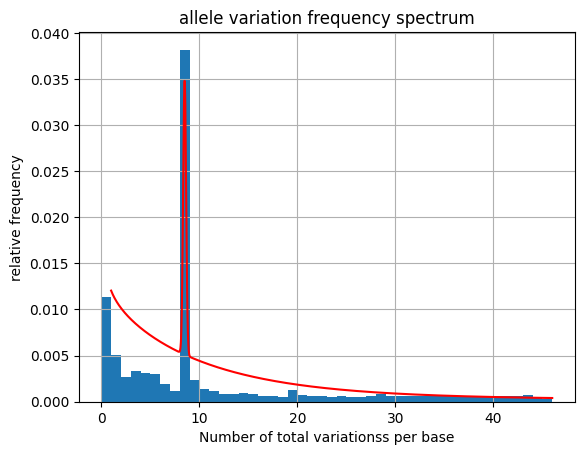

/tmp/ipykernel_23841/2627074892.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


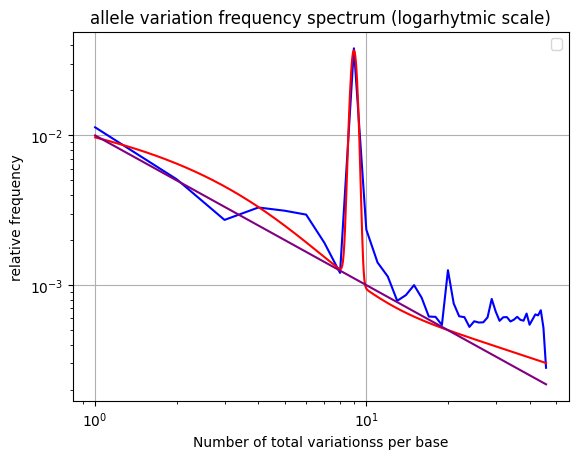

In [49]:
#4.AVARs PDF HISTOGRAM AND FITTING CURVE 

a=min(number_avars)
b=max(number_avars)

x_continuous = np.linspace(a,b,1000)
plt.figure(1)
plt.stairs(avar_SNP_frequency, np.append([0], number_avars), fill = True)
plt.plot(x_continuous, mixture_pdf(x_continuous, 0.03, 8.5, 0.15, 0.01, 0.1)+ 0.003*np.pow(x_continuous, -0.6), color = 'red')
plt.title('allele variation frequency spectrum') #numerical fits for the covariance roughly estimated through covariance
plt.xlabel('Number of total variationss per base')
plt.ylabel('relative frequency')
plt.grid(visible = 'True')
plt.legend
plt.show()

plt.figure(2)
plt.loglog(number_avars, avar_SNP_frequency, color = 'blue')
plt.loglog(x_continuous,  mixture_pdf(x_continuous, 0.036, 9, 0.25, 0.01, 0.4) + 0.003*np.pow(x_continuous, -0.6), color = 'red')
plt.loglog(x_continuous, 0.01/x_continuous, color = 'purple')
plt.title('allele variation frequency spectrum (logarhytmic scale)') #numerical fits for the covariance asked to AI except for variance
plt.xlabel('Number of total variationss per base') #and adjust through trials
plt.ylabel('relative frequency')
plt.grid(visible = 'True')
plt.legend()
plt.show()



In [7]:
#5. IMPLEMENTING A TOOL that, giving a certain number of AVARs, analyzes how many times a column with that
#number of AVARs appears (for all columns)

avar_requested = -1

while True:
    try:
        avar_requested =int(input("What's the number of allele variations you want to check?"))
        if 0<avar_requested<b+1:
            break
        else:
            raise ValueError
    except ValueError:
        print(f'The number of avar requested must be an integer between 1 and {b}')
        
#now that I have the number of allele variations I wanto to check, i need to create an array with only the columns with 
#that number of allele variations and then compared them 'vertically' (each single term of a 1-length-column with the input)

only_avar_columns = (avars_per_base==avar_requested).any(axis=0)

only_avar_req_matrix = bin_mat[:, only_avar_columns] #with this, I apply the filter to the indexes of the columns in the
#construction of the actual matrix

#up until now, we're doing great. The columns are being filtered properly
#now I must compare every column with each other. A good idea should be to use again unique

unique_columns, unique_avar_frequency = np.unique(only_avar_req_matrix, axis=1, return_counts=True)

#axis = 1 because we want to confront the vertical elemnts, not the horizontal ones. The length of each column is still 92,
#and if we send 9 as the number of allele variations, each of them will preserve the 9 variations in their fixed position
#Moreover, if we 
print(len(unique_avar_frequency))
#we get, for avar_requested = 9, the number 893. This means that there is a total of 893 different ways of how a single base has
#actually modified, which is way less than all the possible ones (2^92).

unique_avar_frequency = unique_avar_frequency / np.sum(only_avar_columns) #put a # at the beginning of the row to get
#absolute frequencies instead of relative ones

#BE CAREFUL: len of only_avar_columns is still the length of all the columns with a single SNPs, whereas you need only the 
# number of columns where this information is true. You can do this by summing together all the boolean values, 
#since all the trues are coinverted to ones whereas the others are converted to 0s


high_freq = max(unique_avar_frequency)




        



824


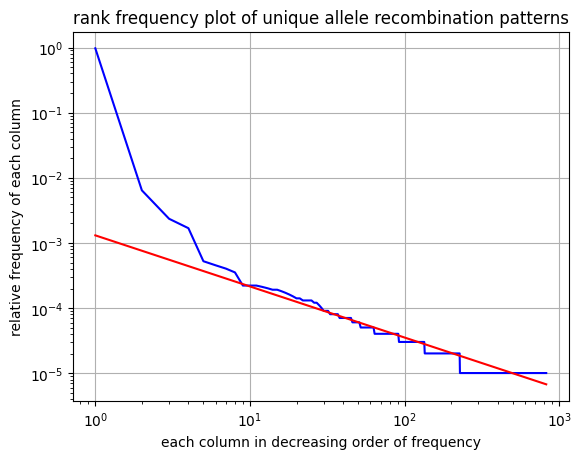

In [8]:
#6. Histogram of the frequencies of unique allele recombination patterns with the same quantity of SNPs
#To create a plot/histogram,

unique_avar_frequency_sorted = np.array(sorted(unique_avar_frequency, reverse = True))
#let's just create an index from 0 to len(unique columns) in order to create a decremental plot
x_axis_avar_rfp = np.array(range(1, len(unique_columns[0, :])+1)) #for logarhytmic graphs, let's just not include the 0, also because of the problems
#it creates during division

#Let's build an estimator for the best alfa coefficient to approximate the dataset to a k/x^alfa function

#To do this, the wasiest way possible is to make the dataset logarhytmic, in order to transform y=k/x^alfa
#to log(y) = -alfa * log(x) + ln(k) (with log(y) and log(x) as variables)
#then, I just do a polyfit with grade 1 to minimize the mean squared error and I find the line
#the coefficent of the line is alfa, whereas its isolated term will be elevated to e and multiplied

log_y_rpf = np.log(unique_avar_frequency_sorted)
log_x_rpf = np.log(x_axis_avar_rfp)

[alpha_rpf, lnk_rpf] = np.polyfit(log_x_rpf, log_y_rpf, 1)

k_rpf=np.exp(lnk_rpf)

plt.figure(3)
plt.loglog(x_axis_avar_rfp, unique_avar_frequency_sorted, color = 'blue')
plt.loglog(x_axis_avar_rfp, k_rpf/pow(x_axis_avar_rfp, -alpha_rpf), color = 'red')
#this estimate was built on n=9. It is expected to suit data only when there is a significant spike in the probability
#density function of the presence of unique columns, in decremental order
plt.title('rank frequency plot of unique allele recombination patterns')
plt.xlabel('each column in decreasing order of frequency') 
plt.ylabel('relative frequency of each column')
plt.grid(visible = 'True')
plt.legend
plt.show()

#RESULTS AND COMMENTS 

#As the plot shows the frequency of columns with the same allele variation frequency (9 variations), there's a significant spike
#in the count of unique columns. The column related to the biggest index shows therefore that the groups of bacteria
#featuring the most frequent columns will have developed on a significantly separate branch from all the others, probably with
#a really further common ancestor considering this high number of same variations patterns.

#trying other input values, however, we can notice how these peaks aren't that occasional, but high spikes can be 
#often reconnected to only a couple values at best, except for 1,2,3 avar_requested, where the peak is slightly higher. However,
#this would only mean that not more than 2 to 3 species have developed with a closer common ancestor, which is not surprising at
#all

#the adaptment of the power-log function for the rfp works, but it was more ideated to fit the negative CDF
#The lowest chance for existing columns is 10^-5 for avar_required=9.



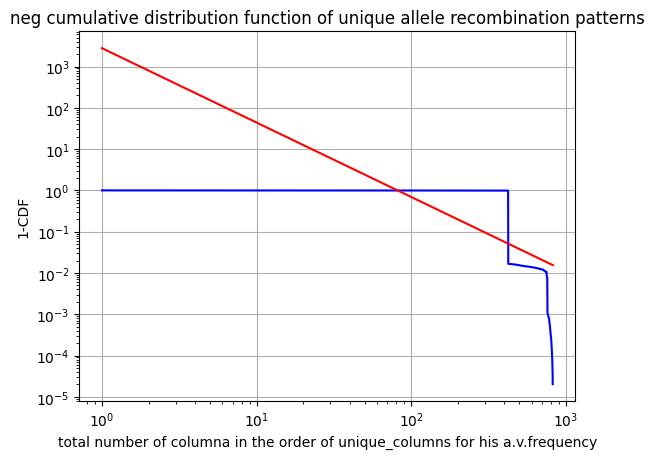

In [9]:
#7.#LET'S ALSO BUILD AND PLOT THE DISCRETE CDF (Cumulative Density Function) for the unique columns 
#more used as 1-CDF by Erik's group not to be forced to order the frequencies from highest to lowest



neg_unique_avar_CDF = 1+-np.cumsum(unique_avar_frequency)  #pow 10,-50 not to make the function collapse to neginf

log_y_cdf = np.log(neg_unique_avar_CDF)
log_x_cdf = np.log(x_axis_avar_rfp) #we're using the same number of x points as rfp, just not rearranging the y decrementally
#(we don't need to do so in the CDF). It's just a way to indicate the column of the unique_column array
#without having to represent in some other way the column

[alpha_cdf, lnk_cdf] = np.polyfit(log_x_cdf[:-2], log_y_cdf[:-2], 1)

k_cdf=np.exp(lnk_cdf)

plt.figure(4)
plt.loglog(x_axis_avar_rfp[:-2], neg_unique_avar_CDF[:-2], color = 'blue')
plt.loglog(x_axis_avar_rfp, k_cdf/pow(x_axis_avar_rfp, -alpha_cdf), color = 'red')
#this estimate was built on n=9. It is expected to suit data only when there is a significant spike in the probability
#density function of the presence of unique columns, in decremental order
plt.title('neg cumulative distribution function of unique allele recombination patterns') 
plt.xlabel('total number of columna in the order of unique_columns for his a.v.frequency')
plt.ylabel('1-CDF')
plt.grid(visible = 'True')
plt.legend
plt.show()

#results 
#The final drop for the various CDFs is perfectly explainable for every number with a chance of around 10ì-5 IT WILL OCCUR
#all the others drop of order are insignificant on the plot compared to bigger order drops (10^-1 vs 10^-4 for instance) 
#of the plot, whose position is basically random in our case. but when the last 2 to 5 drop happen, the plot
# rapidly falls towards pow(10, -20). It's a problem of the discrete number and the rapid fall-off starting from

#if I try to draw the plot of the CDF, we can notice that the initial rase would be basically the same.
#However, since we start plotting at 1, we won't see the section of the graph between x=0 and x=1 (log negative x-axis).
#As I don't see the actual 0 in the CDF (cause the first point is already set at 10^-4, the probability the
# first column has to appear among the others), we won't see an exact 1 in the negativeCDF: the best we will see is a 1-the
#probability of the first column. But since we can see the 1 in the CDF, we can see the 'almost 0' (around 10^-5 as we wrote)
#in the negative CDF.

#to remove the final drop, exclude the last element of the array using [:-2]. Its probability density will be the last y you find
#of the graph


50
230
477
639
695
722
757
777


/tmp/ipykernel_52200/2016239052.py:28: RuntimeWarning: invalid value encountered in log
  log_y_cdf = np.log(neg_unique_avar_CDF)


824
814
842
930
959
906
827
794
788
783
816
733
741
729
764
759
742
780
749
781
829
779
828
845
862
872
858
814
797
816
861
828
882
840
853
859


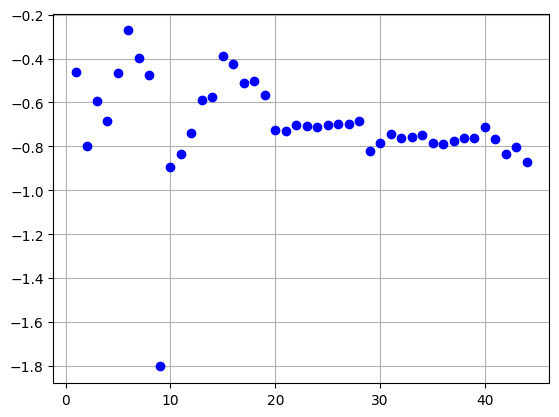

In [10]:
#8. create a plot that puts on the x axis the number n of allele  variations for each group of unique columns
#and on the Y axis HE ALFA COEFFICIENT OF 1/n^alfa that suits the most the 1-CDF of each n-allele-variations group
n = np.array(range(1, b-1))
alpha_n = np.zeros(b-2, dtype = float)

for avar_requested in n: #let's just replicate the process in an iterative way
    
    only_avar_columns = (avars_per_base==avar_requested).any(axis=0)

    only_avar_req_matrix = bin_mat[:, only_avar_columns]

    unique_columns, unique_avar_frequency = np.unique(only_avar_req_matrix, axis=1, return_counts=True)

 
    print(len(unique_avar_frequency))
 

    unique_avar_frequency = unique_avar_frequency / np.sum(only_avar_columns) 


    high_freq = max(unique_avar_frequency)
    
    x_axis_avar_rfp = np.array(range(1, len(unique_columns[0, :])+1))
    
    
    neg_unique_avar_CDF = 1+pow(10, -15)-np.cumsum(unique_avar_frequency)  

    log_y_cdf = np.log(neg_unique_avar_CDF)
    log_x_cdf = np.log(x_axis_avar_rfp) 

    [alpha_cdf, lnk_cdf] = np.polyfit(log_x_cdf[ :-2], log_y_cdf[:-2], 1)
    
    alpha_n[avar_requested-1] = alpha_cdf
 


plt.figure(5)
plt.plot(n, alpha_n, 'o', color = 'blue', linestyle = '')
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.grid(visible = 'True')
plt.legend
plt.show()


In [50]:
#9. EVALUATING THE LENGTH OF EVERY POSSIBLE TREE-COMPATIBLE CONSECUTIVE n-SNPs : THE LOGIC BEHIND THE ALGORHYTHM

#FIRST OF ALL, remember that we don't have to work with all 0s columns. These columns are always compatible evolutionally since they haven't 
#suffered any mutation, neither evolutionally nor by recombination (genes have not been involved in evolution). We'll only
#consider the number of consecutive SNPs, since they are the closest in the genome and the ones that, 
#together, might have not suffered recombination.

#What we are assuming is that every base is only able to mutate once, because if we exclude recombination, the chances of having more than one
#occurence during the mutation is mu, in the order of 10 to the power of -10. Multiplied with 2 elevated to the power of generations, since we have around 30,
#we get a chance of every base to mutate of 2^30*10^-10 = approximately 10%, which resembles the number of columns (and therefore genes) that 
#have occured at least one single mutation. 


#Differently, the chance of having two occurences of mutation for the same gene in the same tree is mu^2, which mutiplied by the population 
#still is a  10^-11 chance. Therefore, if we see that a single base must have suffered the same mutation twice or more in the same tree,
#we can assume it was of recombination.

#Having a certain allele frequency variation doesn't necessarly mean that more than 1 mutation along the tree has occured. If there is 
#compatibility, it just means that the mutation has occured closer to the origin of the tree.

#To check the compatibility among two genes, the best way is to compare their columns, which will have the sequences 00, 01, 10, 11:
#if all four of them appear, it'll mean there's been a first division (00 and 10, let's say) and, then, in both these branches
#the second base will have mutated. The chance of this happening are extremely low, as we said, without recombination.

#To check compatibility among n genes, we must make sure that every gene is compatible with all the previous of its group.
#If that's true, we can try to expand the group further until we find a breaking point, after which we fix the length of the group and we
#build a new group from the last failing gene.

#With 0 recombination, all genes will be compatible to each other. The shorter the length of SNPs is, the more likely is recombination
#to occur.

In [51]:
#9.1 creating a function with less use of numpy to do the 4-gamete-test between two bases (NOT WORKING)

def single_gamete_test(b1, b2): #b1 and b2 will be the two rows I'm building the test for
    
    gametes = [(c1,c2) for c1,c2 in zip(b1,b2)]
    
    return len(set(gametes))

#hypotetical function to do a single gamete test with only python and not numpy variables, instead of decimalizing and np.unique
#returns as the result the lengthj to compare to 4
    
    
    
    

In [52]:
#10. Implementing the 4-gamete-test to understand the length of each tree compatible n-SNP, then stored in a vector

n_SNP_lengths = []
current_n_SNP_length = 1 #setting up the first assumption: an n-SNP can't be shorter than 1

clash_indexes = []

current_n_SNP =  bin_mat[:, 0]  #the first test has to be with the first base

#BE CAREFUL: here, the columns become row vector when they get written as in th eline before




for i in range(1, n_SNP_columns): #I exclude 0 since I've already uploaded it. i will only need to upload all the columns until the 
    #last one, whose index is len-1
    
    current_n_SNP = np.vstack((current_n_SNP, bin_mat[:, i]))
    
    for j in range(0,i-np.sum(n_SNP_lengths, dtype=int)): #i must come back to 1 whenever I have found an incompatibility: this is
        #the way to do so
        
        test_matrix = np.vstack((current_n_SNP[j, :], current_n_SNP[-1, :])) #let's do one comparison between the new vector and one of 
        #the previous
        test_matrix_decimal = 2*test_matrix[0, :] + test_matrix[1,:] #I use decimals to accelerate the checking procedure. every 00 is turned
        #into a 0, 01 to a 1, 10 to 2 and 11 to 3 (read from top to bottom)
        unique_columns = np.unique(test_matrix_decimal) # i found all the unique columns
        
        if len(unique_columns) == 4 or i == n_SNP_columns-1:
            
            n_SNP_lengths.append(current_n_SNP_length) #save the length of my n_SNP
            current_n_SNP_length = 0 #reset the counter to 1 (putting 0 because the +1 will arrivare anyways)
            current_n_SNP = [bin_mat[:, i]] #reset the current SNP
            clash_indexes.append(i) #in order to have the clash_indexes built on python enumeration style
            if i == n_SNP_columns-1:
                n_SNP_lengths[-1] += 1
            break

    current_n_SNP_length += 1
        



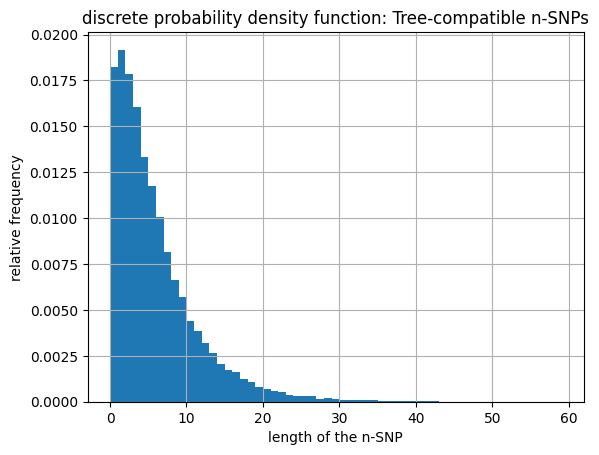

In [53]:
#11. CREATING THE discrete pdf vector for all the possible lengths of an n_SNP and then the histogram

sorted_lengths, lengths_frequencies = np.unique(n_SNP_lengths, return_counts=True)

lengths_frequencies = np.array(lengths_frequencies).view()/np.sum(n_SNP_lengths) #denominator equal to the number of columns of bin_mat

plt.figure(7)
plt.stairs(lengths_frequencies, np.append([0], sorted_lengths), fill = True)
plt.title('discrete probability density function: Tree-compatible n-SNPs') #numerical fits for the covariance roughly estimated through covariance
plt.xlabel('length of the n-SNP')
plt.ylabel('relative frequency')
plt.grid(visible = 'True')
plt.legend
plt.show()

In [54]:
#12. General recombination ratio (clashes/total mutations) and reassessing where the 2-gene clashes are in the original genome

general_recombination_ratio = len(clash_indexes) / n_bases


#to find the recombinations, I need to do again the indexing filter I did with the only_SNP_columns and the only_SNP_columns_2chars

only_clashes_columns = only_SNP_columns_2letters.copy() #let's copy the last filtered array of SNP columns, with the 3 letters SNP removed
#this will have the original length of the core genome but the true numbers of the length of the bin_mat

#now, the big difference is that this time clash_indexes is not a Boolean array and indicates the length of bin_mat rows, the same as
#the number of only_SNP_columns_2letters True indexes

clashes_filter = np.zeros(n_SNP_columns, dtype = bool)

for i in clash_indexes:
    clashes_filter[i] =  True   #with this loop, I create a filter where every index of the length of the bin_mat not inside clash_indexes is a false


only_clashes_columns[only_SNP_columns_2letters] = clashes_filter #with this, I do the same procedure as in STEP 2.
#Take all the indexes true inside the original only_SNP_columns_2letters
#which was copied in a ews variable, and after that assigning the value that indicates if there is a clash or not in each column
    
num_kilobases = 1 + int(n_bases / 1000)

clashes_frequency_kb = []

for i in range (0, num_kilobases):
    
    clashes_frequency_kb.append(np.sum(only_clashes_columns[1000*i : 1000*(i+1)]))


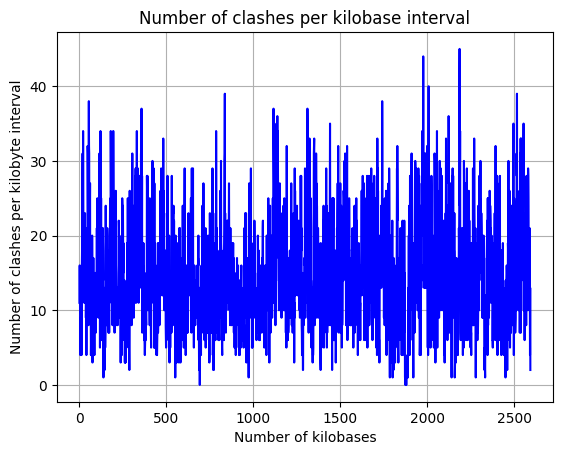

In [55]:
#13. PLOTTING THE NUMBER OF CLASHES FOR EACH KB

plt.figure(9)
plt.plot(range(1, num_kilobases+1), clashes_frequency_kb, color = 'blue')
plt.title('Number of clashes per kilobase interval')
plt.xlabel('Number of kilobases')
plt.ylabel('Number of clashes per kilobyte interval')
plt.grid(visible = 'True')
plt.legend
plt.show()

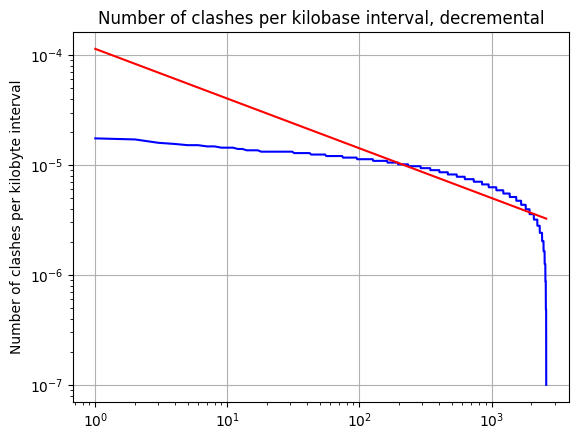

692
1874
1879
1880


In [56]:
#14. PLOTTING THE FREQUENCIES OF CLASHES PER KB in a rank frequency plot

decr_clashes_frequency_kb = np.array(sorted(clashes_frequency_kb, reverse = True))

total_clashes_per_kb, total_clashes_per_kb_freq = np.unique(clashes_frequency_kb, return_counts = True)

decr_clashes_frequency_kb = decr_clashes_frequency_kb / n_bases + pow(10, -7)

log_y_clashes = np.log(decr_clashes_frequency_kb) 
log_x_clashes = np.log(range(1, num_kilobases+1))

[alpha_rpf_clash, lnk_rpf_clash] = np.polyfit(log_x_clashes, log_y_clashes, 1)

k_rpf_clash=np.exp(lnk_rpf_clash)

plt.figure(10)
plt.loglog(range(1, num_kilobases+1), decr_clashes_frequency_kb, color = 'blue')
plt.loglog(range(1, num_kilobases+1), k_rpf_clash/pow(range(1, num_kilobases+1), -alpha_rpf_clash), color = 'red')
plt.title('Number of clashes per kilobase interval, decremental')
plt.xlabel('')
plt.ylabel('Number of clashes per kilobyte interval')
plt.grid(visible = 'True')
plt.legend
plt.show()

#il fatto che si arrivi a 10-7, posto come pedina per non far crollare a 0 gli altri valori, fa capire come alcune basi
#si siano effettivamente sviluppate in maniera puramente evolutiva, non avendo clashes e siti di ricombinazione

for i in range(0,num_kilobases):
    
    if clashes_frequency_kb[i] == 0:
        print(i)
        
        #1879 e 1880, assieme a 1874, sono zone di kb intoccate e molto ravvicinate, 

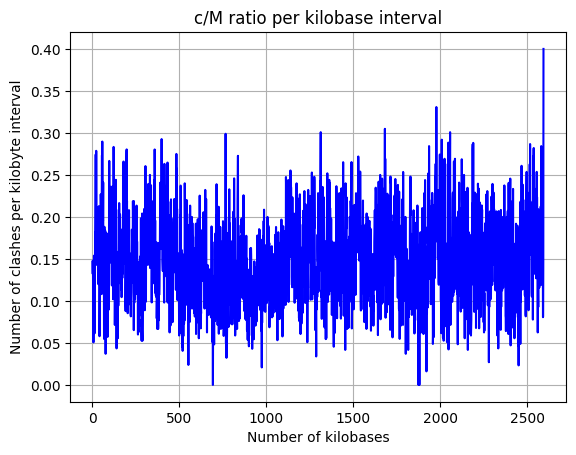

0.14917395557626117


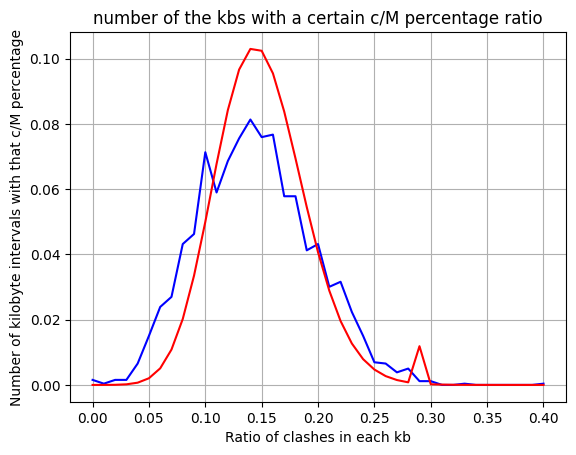

0.0025631011858919784
0.0011838582751270766


In [57]:
#15. Studying the clash-mutation ratio for each kb interval


mutations_frequency_kb = [] #counting only single-letter mutations for our test

for i in range (0, num_kilobases):
    
    mutations_frequency_kb.append(np.sum(only_SNP_columns_2letters[1000*i : 1000*(i+1)]))
    
clash_mutation_ratio_kb = np.array(clashes_frequency_kb) / np.array(mutations_frequency_kb)

plt.figure(10)
plt.plot(range(1, num_kilobases+1), clash_mutation_ratio_kb, color = 'blue')
plt.title('c/M ratio per kilobase interval')
plt.xlabel('Number of kilobases')
plt.ylabel('Number of clashes per kilobyte interval')
plt.grid(visible = 'True')
plt.show()

#since we have all these probabilities that may vary from each other (they don't go over 0.4), let's analyze them in blocks of 0.01

#we will have to work with poisson, which uses integers: let's therefore consider as a unique group all the kilobases with 
#a percentage c_M between 10 and 11%, 11 and 12% and so on
c_M_ratio_discrete_intervals = np.linspace(0, 0.4, num = int(100*max(clash_mutation_ratio_kb) + 1))

c_M_intervals_counter = list((c_M_ratio_discrete_intervals)*0) #now we want to create the counter for the number of kbs
#with a specific c/M percentage, between 0% and 0.99%, 1% and 1.99% and so on
c_M_intervals_counter[-1] = 1


for i in range(0, 41):  #this is the counter to understand how many kb intervals are inside a single percentage point
    
    for j in range(0, num_kilobases-1):
        
        if  float(i)/100 <= clash_mutation_ratio_kb[j] < float(i + 1)*0.01:
            
            c_M_intervals_counter[i] += 1
            
c_M_intervals_freq = np.array(c_M_intervals_counter) / num_kilobases
        
        
clashes_per_kb_perc_avg = np.average(clash_mutation_ratio_kb*100) #the ratio is still not a percentage, so we will have to
#multiply it. We will use original dataset and not the discretized one to have more reliable conclusion, but we need
#the percentage because in Poisson we have to use natural numbers (1 instead of 0.01, 40 instead of .4 and so on)
#as random variables, and to mantain the function balanced we have to raise the original avg by 100

c_M_perc_discrete_intervals = c_M_ratio_discrete_intervals * 100


print(clashes_per_kb_perc_avg/100) #this is the exact average of the c/M ratio, a little bit more precise than the one we would get
#through discretization

poisson_distr_cmratio = [] #not let's build the poisson distribution related to percentages

for i in c_M_ratio_discrete_intervals:
    poisson_distr_cmratio.append(pow(clashes_per_kb_perc_avg,i*100) * math.exp(-clashes_per_kb_perc_avg) / math.factorial(int(i*100)))

plt.figure(11)
plt.plot(c_M_ratio_discrete_intervals, c_M_intervals_freq, color = 'blue')
plt.plot(c_M_ratio_discrete_intervals, poisson_distr_cmratio, color = 'red')
plt.title('number of the kbs with a certain c/M percentage ratio')
plt.xlabel('Ratio of clashes in each kb')
plt.ylabel('Number of kilobyte intervals with that c/M percentage')
plt.grid(visible = 'True')
plt.show()

#The poisson estimate is clearly less variant compared to the original one, despite having the rigth average

data_variance_percentage = np.var(clash_mutation_ratio_kb)
print(data_variance_percentage) 
print(np.var(poisson_distr_cmratio)) #0.002563 vs the poisson's 0.001183 (poisson variance way similar to the average, lambda, 
#the more data you get)


4.621011115095016


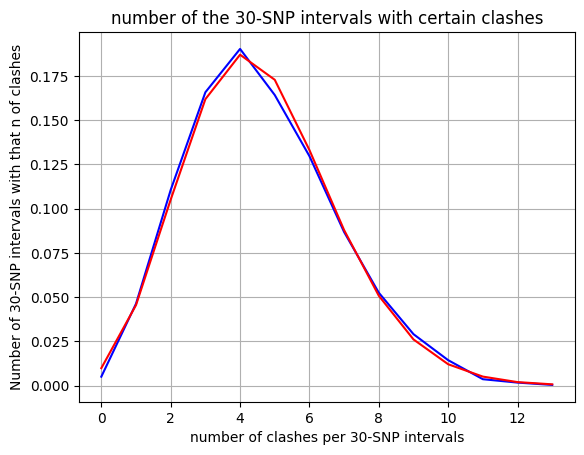

4.576458258153018


In [58]:
#16. Studying the clash frequency for each 10-20-30-40SNP indexes. We will use the clash_indexes that are related to the original
#only_SNP_filtered matrix.

SNP_intervals_length = [40,20,30,10]

SNP_intervals_border_40 = list(range(0, n_SNP_columns+3, SNP_intervals_length[0])) #the number of genes is 250968

SNP_intervals_border_20 = list(range(0, n_SNP_columns+13, SNP_intervals_length[1])) #to absorb the last 8, you need to increase the range

SNP_intervals_border_30 = list(range(0, n_SNP_columns+13, SNP_intervals_length[2])) #here, 8 becomes 18

SNP_intervals_border_10 = list(range(0, n_SNP_columns+3, SNP_intervals_length[3]))

clashes_in_40SNP_counter = np.zeros(len(SNP_intervals_border_40))
clashes_in_20SNP_counter = np.zeros(len(SNP_intervals_border_20))
clashes_in_30SNP_counter = np.zeros(len(SNP_intervals_border_30))
clashes_in_10SNP_counter = np.zeros(len(SNP_intervals_border_10))


for i in clash_indexes:
    
    clashes_in_40SNP_counter[i//40] += 1
    clashes_in_20SNP_counter[i//20] += 1
    clashes_in_30SNP_counter[i//30] += 1
    clashes_in_10SNP_counter[i//10] += 1
    

#let's develop the plot for 30-SNP-interval

max_clashes_per_SNP_30 = max(clashes_in_30SNP_counter)      #at best, 13 clashes      
            
clashes_frequencies_30SNP = np.zeros(int(max_clashes_per_SNP_30)+1)

for j in clashes_in_30SNP_counter:
    
    clashes_frequencies_30SNP[int(j)] += 1
    
    
clashes_frequencies_30SNP = clashes_frequencies_30SNP/len(clashes_in_30SNP_counter)
possible_n_clashes_30SNP = range(0,int(max_clashes_per_SNP_30)+1)
clashes_in_30SNP_avg = np.average(clashes_in_30SNP_counter)

print(clashes_in_30SNP_avg)

poisson_clashes_30SNP = []

for i in possible_n_clashes_30SNP:
    poisson_clashes_30SNP.append(pow(clashes_in_30SNP_avg,i) * math.exp(-clashes_in_30SNP_avg) / math.factorial(int(i)))
    
    plt.figure(11)
plt.plot(possible_n_clashes_30SNP, clashes_frequencies_30SNP, color = 'blue')
plt.plot(possible_n_clashes_30SNP, poisson_clashes_30SNP, color = 'red')
plt.title('number of the 30-SNP intervals with certain clashes')
plt.xlabel('number of clashes per 30-SNP intervals')
plt.ylabel('Number of 30-SNP intervals with that n of clashes')
plt.grid(visible = 'True')
plt.show()

data_variance_c_per_SNP = np.var(clashes_in_30SNP_counter)
print(data_variance_c_per_SNP) #4.57 versus the average 4.61 -> EXTREMELY SIMILAR TO THE AVG

6.161593625498008


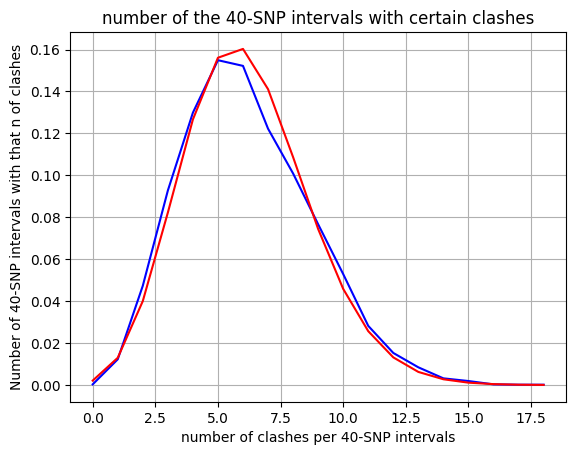

6.723528934461358
3.080796812749004


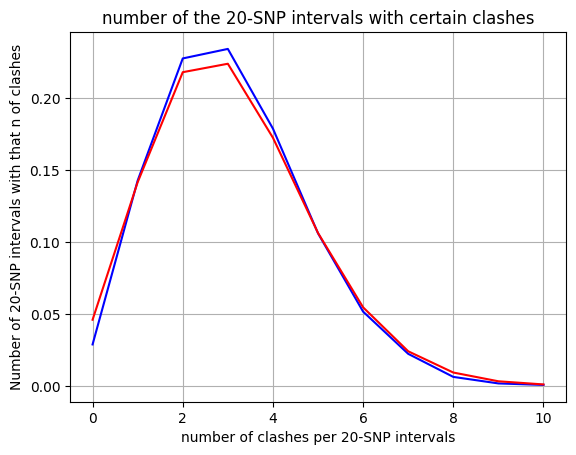

2.7195276519420326
1.5405211570643078


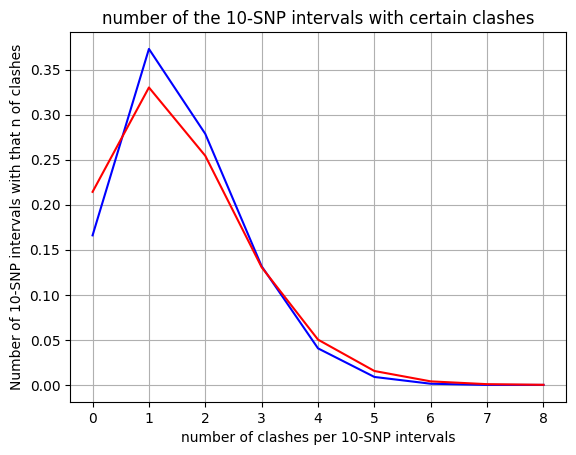

1.2238142474805005


In [59]:
#16.1 LET'S DO THE SAME THING FOR 10, 20 AND 40

max_clashes_per_SNP_40 = max(clashes_in_40SNP_counter)      #at best, 13 clashes      
            
clashes_frequencies_40SNP = np.zeros(int(max_clashes_per_SNP_40)+1)

for j in clashes_in_40SNP_counter:
    
    clashes_frequencies_40SNP[int(j)] += 1
    
    
clashes_frequencies_40SNP = clashes_frequencies_40SNP/len(clashes_in_40SNP_counter)
possible_n_clashes_40SNP = range(0,int(max_clashes_per_SNP_40)+1)
clashes_in_40SNP_avg = np.average(clashes_in_40SNP_counter)

print(clashes_in_40SNP_avg)

poisson_clashes_40SNP = []

for i in possible_n_clashes_40SNP:
    poisson_clashes_40SNP.append(pow(clashes_in_40SNP_avg,i) * math.exp(-clashes_in_40SNP_avg) / math.factorial(int(i)))
    
    plt.figure(12)
plt.plot(possible_n_clashes_40SNP, clashes_frequencies_40SNP, color = 'blue')
plt.plot(possible_n_clashes_40SNP, poisson_clashes_40SNP, color = 'red')
plt.title('number of the 40-SNP intervals with certain clashes')
plt.xlabel('number of clashes per 40-SNP intervals')
plt.ylabel('Number of 40-SNP intervals with that n of clashes')
plt.grid(visible = 'True')
plt.show()
data_variance_c_per_SNP_40 = np.var(clashes_in_40SNP_counter)
print(data_variance_c_per_SNP_40) #still similar to the avg



#AGAIN WITH n=20

max_clashes_per_SNP_20 = max(clashes_in_20SNP_counter)      #at best, 13 clashes      
            
clashes_frequencies_20SNP = np.zeros(int(max_clashes_per_SNP_20)+1)

for j in clashes_in_20SNP_counter:
    
    clashes_frequencies_20SNP[int(j)] += 1
    
    
clashes_frequencies_20SNP = clashes_frequencies_20SNP/len(clashes_in_20SNP_counter)
possible_n_clashes_20SNP = range(0,int(max_clashes_per_SNP_20)+1)
clashes_in_20SNP_avg = np.average(clashes_in_20SNP_counter)

print(clashes_in_20SNP_avg)

poisson_clashes_20SNP = []

for i in possible_n_clashes_20SNP:
    poisson_clashes_20SNP.append(pow(clashes_in_20SNP_avg,i) * math.exp(-clashes_in_20SNP_avg) / math.factorial(int(i)))
    
    plt.figure(13)
plt.plot(possible_n_clashes_20SNP, clashes_frequencies_20SNP, color = 'blue')
plt.plot(possible_n_clashes_20SNP, poisson_clashes_20SNP, color = 'red')
plt.title('number of the 20-SNP intervals with certain clashes')
plt.xlabel('number of clashes per 20-SNP intervals')
plt.ylabel('Number of 20-SNP intervals with that n of clashes')
plt.grid(visible = 'True')
plt.show()

data_variance_c_per_SNP_20 = np.var(clashes_in_20SNP_counter)
print(data_variance_c_per_SNP_20) #still similar to the avg


#AGAIN WITH n=10

max_clashes_per_SNP_10 = max(clashes_in_10SNP_counter)      #at best, 13 clashes      
            
clashes_frequencies_10SNP = np.zeros(int(max_clashes_per_SNP_10)+1)

for j in clashes_in_10SNP_counter:
    
    clashes_frequencies_10SNP[int(j)] += 1
    
    
clashes_frequencies_10SNP = clashes_frequencies_10SNP/len(clashes_in_10SNP_counter)
possible_n_clashes_10SNP = range(0,int(max_clashes_per_SNP_10)+1)
clashes_in_10SNP_avg = np.average(clashes_in_10SNP_counter)

print(clashes_in_10SNP_avg)

poisson_clashes_10SNP = []

for i in possible_n_clashes_10SNP:
    poisson_clashes_10SNP.append(pow(clashes_in_10SNP_avg,i) * math.exp(-clashes_in_10SNP_avg) / math.factorial(int(i)))
    
    plt.figure(14)
plt.plot(possible_n_clashes_10SNP, clashes_frequencies_10SNP, color = 'blue')
plt.plot(possible_n_clashes_10SNP, poisson_clashes_10SNP, color = 'red')
plt.title('number of the 10-SNP intervals with certain clashes')
plt.xlabel('number of clashes per 10-SNP intervals')
plt.ylabel('Number of 10-SNP intervals with that n of clashes')
plt.grid(visible = 'True')
plt.show()

data_variance_c_per_SNP_10 = np.var(clashes_in_10SNP_counter)
print(data_variance_c_per_SNP_10) #still similar to the avg



/tmp/ipykernel_1103/3208772948.py:26: RuntimeWarning: overflow encountered in scalar power
  poisson_SNP_1kb.append(pow(SNP_per_kb_avg , int(i)) * math.exp(-SNP_per_kb_avg ) / math.factorial(int(i)))


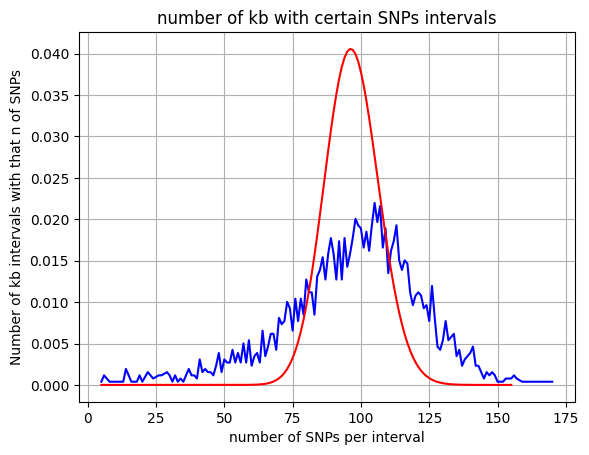

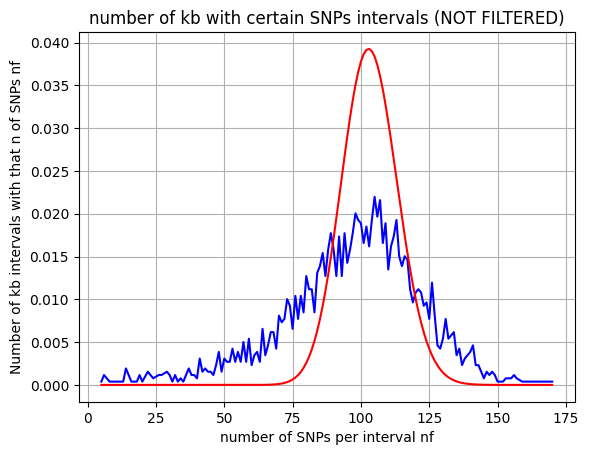

In [ ]:
#17 This POisson distribution is really interesting: let's make sure we're doing things right.
#Let's evaluate how many SNPs are for each kb

SNP_counter_each_kb = []
SNP_counter_each_kb_notfiltered = []

for i in range(0, num_kilobases):
    
    SNP_counter_each_kb.append(np.sum(only_SNP_columns_2letters[i*1000 : 1000*(1+i)]))
    
for i in range(0, num_kilobases):
    
    SNP_counter_each_kb_notfiltered.append(np.sum(only_SNP_columns[i*1000 : 1000*(1+i)]))
    
SNP_per_kb_avg = np.average(SNP_counter_each_kb)
SNP_per_kb_avg_notfiltered = np.average(SNP_counter_each_kb_notfiltered)

possible_SNP_per_kb, SNP_per_kb_frequency = np.unique(SNP_counter_each_kb, return_counts=True)
SNP_per_kb_frequency = SNP_per_kb_frequency / num_kilobases

possible_SNP_per_kb_nf, SNP_per_kb_frequency_nf = np.unique(SNP_counter_each_kb, return_counts=True)
SNP_per_kb_frequency_nf = SNP_per_kb_frequency_nf / num_kilobases
poisson_SNP_1kb = []

for i in possible_SNP_per_kb:
    poisson_SNP_1kb.append(pow(SNP_per_kb_avg , int(i)) * math.exp(-SNP_per_kb_avg ) / math.factorial(int(i)))
    
    
poisson_SNP_1kb_nf =  poisson.pmf(possible_SNP_per_kb_nf, mu = SNP_per_kb_avg_notfiltered)
    
plt.figure(14)
plt.plot(possible_SNP_per_kb, SNP_per_kb_frequency, color = 'blue')
plt.plot(possible_SNP_per_kb, poisson_SNP_1kb, color = 'red')
plt.title('number of kb with certain SNPs intervals')
plt.xlabel('number of SNPs per interval')
plt.ylabel('Number of kb intervals with that n of SNPs')
plt.grid(visible = 'True')
plt.show()

plt.figure(15)
plt.plot(possible_SNP_per_kb_nf, SNP_per_kb_frequency_nf, color = 'blue')
plt.plot(possible_SNP_per_kb_nf, poisson_SNP_1kb_nf, color = 'red')
plt.title('number of kb with certain SNPs intervals (NOT FILTERED)')
plt.xlabel('number of SNPs per interval nf')
plt.ylabel('Number of kb intervals with that n of SNPs nf')
plt.grid(visible = 'True')
plt.show()

#NO POISSON FIT AS EXPECTED IN BOTH CASES ( as it should :) )

11891


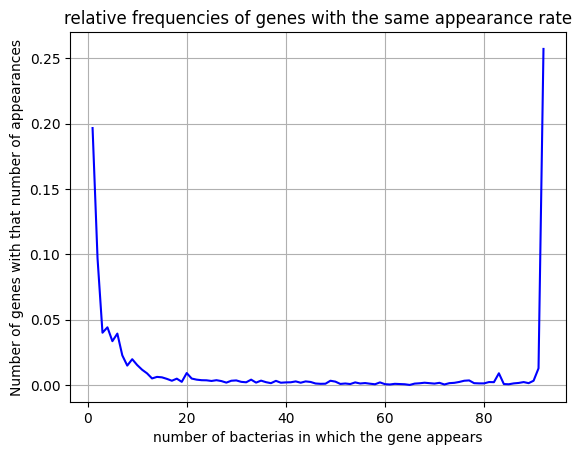

In [ ]:
#18. 

    
    








In [ ]:

print(min(np.sum(genes_occurence_matrix_boolean, axis=1)))



4088
